In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from scipy import stats
import warnings
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

### Load the dataset 

In [3]:
train_file_path = "input/house-prices-advanced-regression-techniques/train.csv"
train_df = pd.read_csv(train_file_path)

## Nettoyage des valeurs aberrantes (Outliers)

--- TOP 10 CORRÉLATIONS ---
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1', 'LotFrontage']


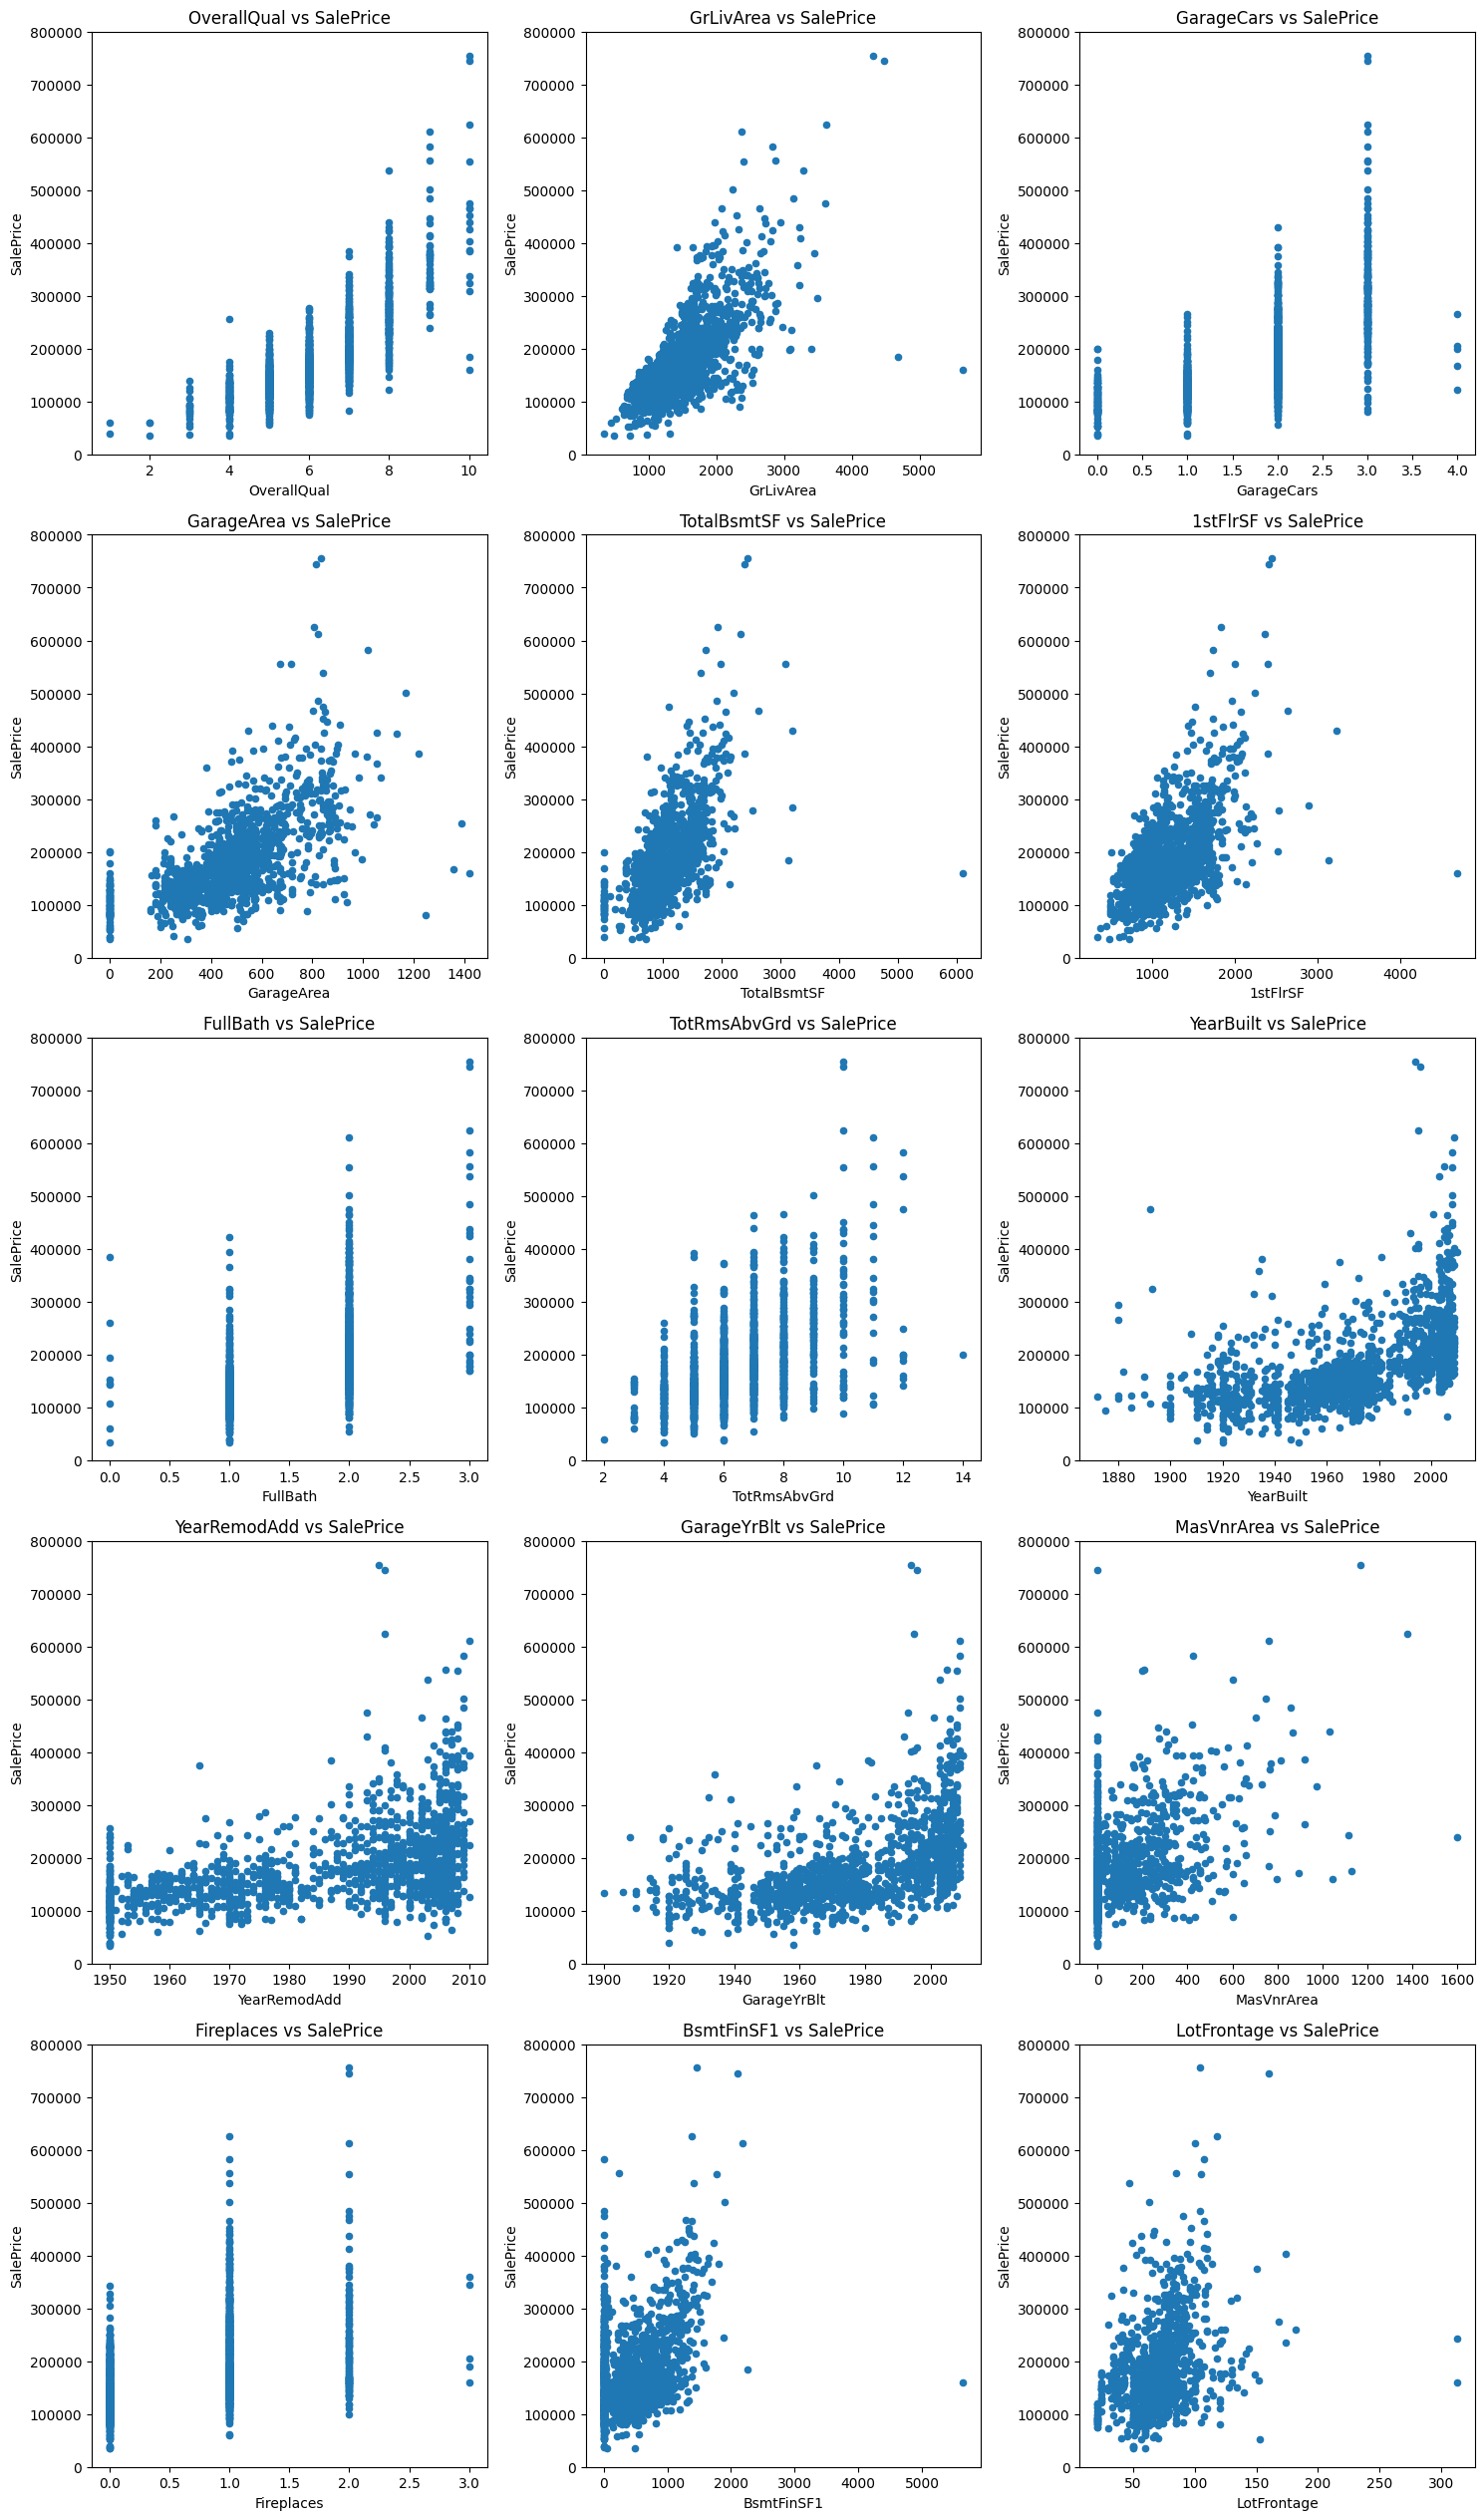

In [4]:
# 1. Identifier les 10 variables les plus corrélées au prix
print("--- TOP 10 CORRÉLATIONS ---")
corr = train_df.select_dtypes(include=['float64', 'int64']).corr()
top_10_cols = corr['SalePrice'].sort_values(ascending=False).head(16).index
top_10_cols = top_10_cols.drop('SalePrice')
print(top_10_cols.tolist())

num_cols = top_10_cols.tolist()

# Create subplots
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 5*(len(num_cols)//3 + 1)))
axes = axes.flatten()

for i, var in enumerate(num_cols):
    data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
    data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), ax=axes[i])
    axes[i].set_title(f'{var} vs SalePrice')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Analyse détaillée de chaque caractéristique du TOP 10

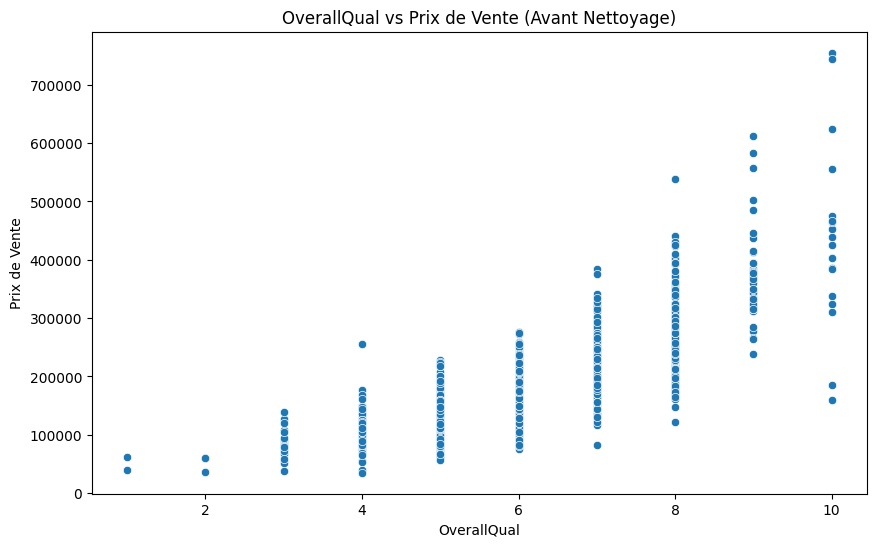

Aucun outlier détecté pour les critères définis


In [5]:
# Caractéristique 1 - OverallQual (Qualité Générale)
feature_name = top_10_cols[0]

# Créer le nuage de points AVANT nettoyage
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

print("Aucun outlier détecté pour les critères définis")


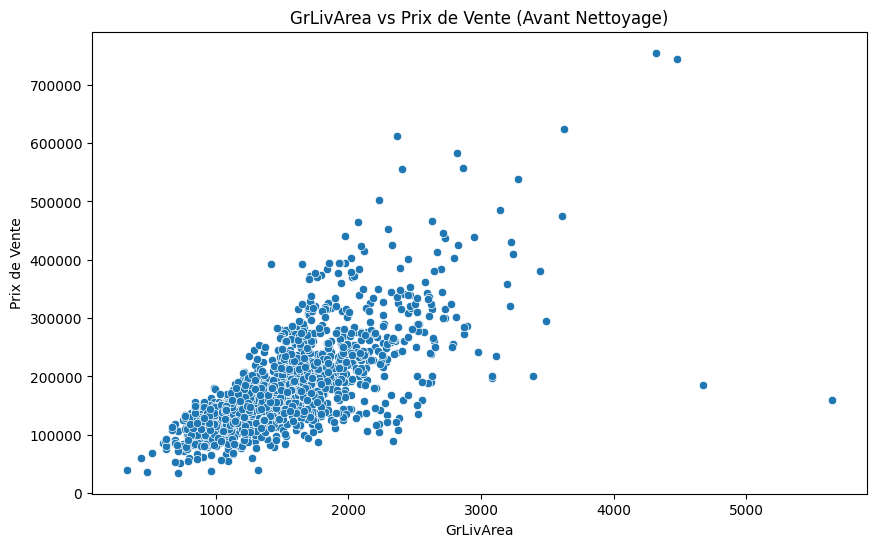


Outliers identifiés : 2
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


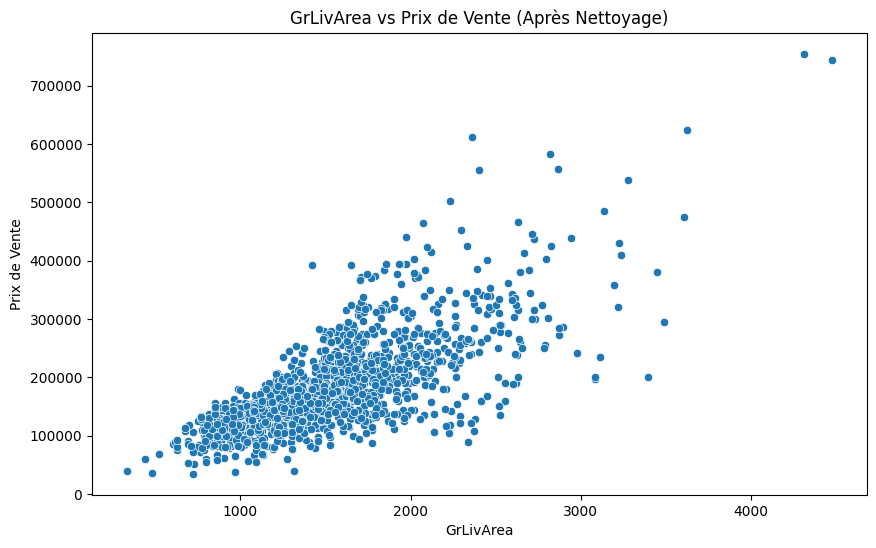

In [6]:
# Caractéristique 2
feature_name = top_10_cols[1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()


outliers = train_df[(train_df[feature_name] > 4000 ) & 
                    (train_df['SalePrice'] < 300000)]
if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


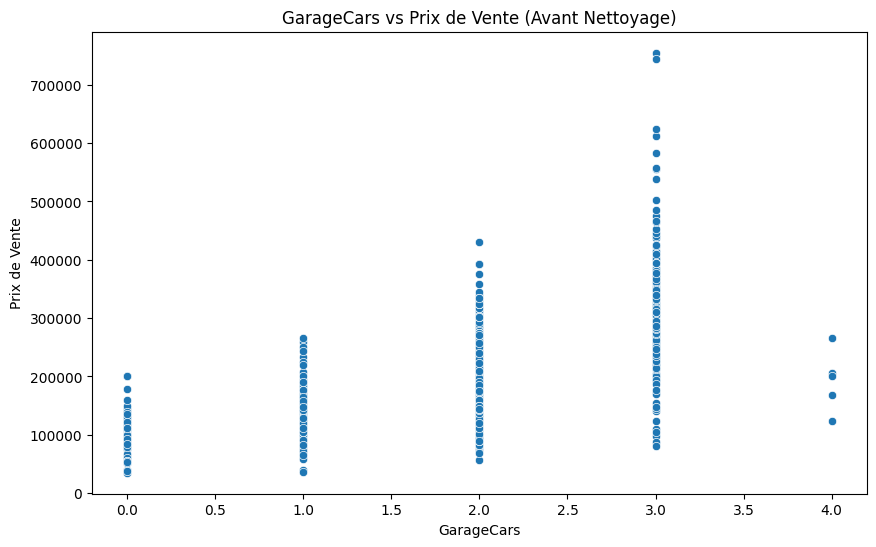


Aucun outlier détecté pour les critères définis


In [7]:
# Caractéristique 3
feature_name = top_10_cols[2]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = []

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


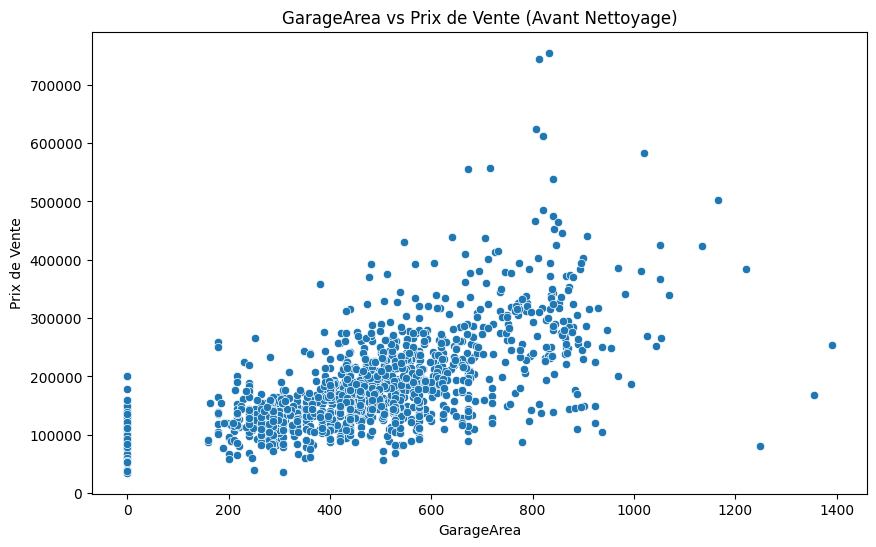


Outliers identifiés : 3
      GarageArea  SalePrice
581         1390     253293
1061        1248      81000
1190        1356     168000


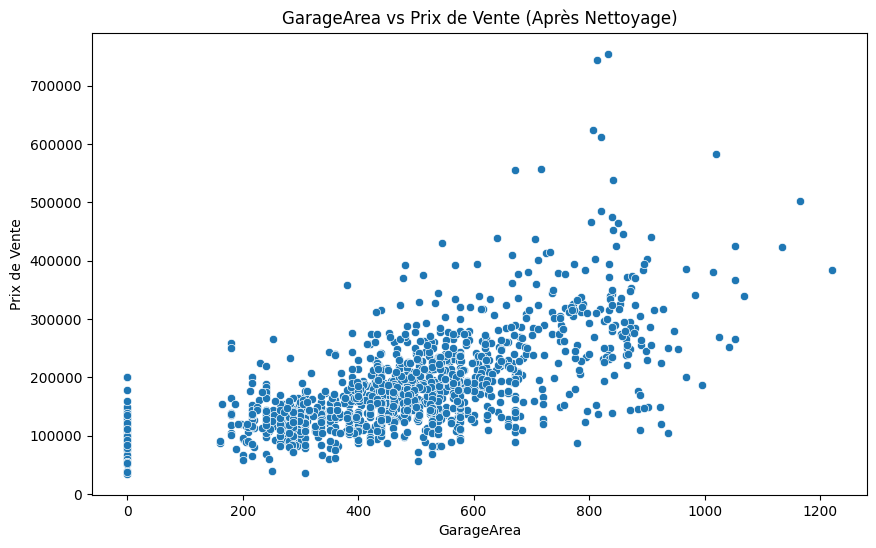

In [8]:
# Caractéristique 4
feature_name = top_10_cols[3]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


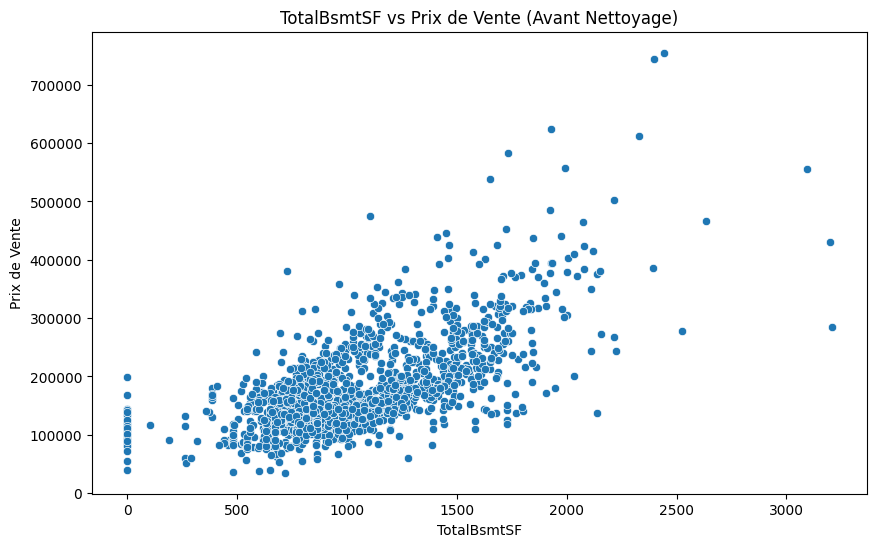


Aucun outlier détecté pour les critères définis


In [9]:
# Caractéristique 5
feature_name = top_10_cols[4]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = [] #train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


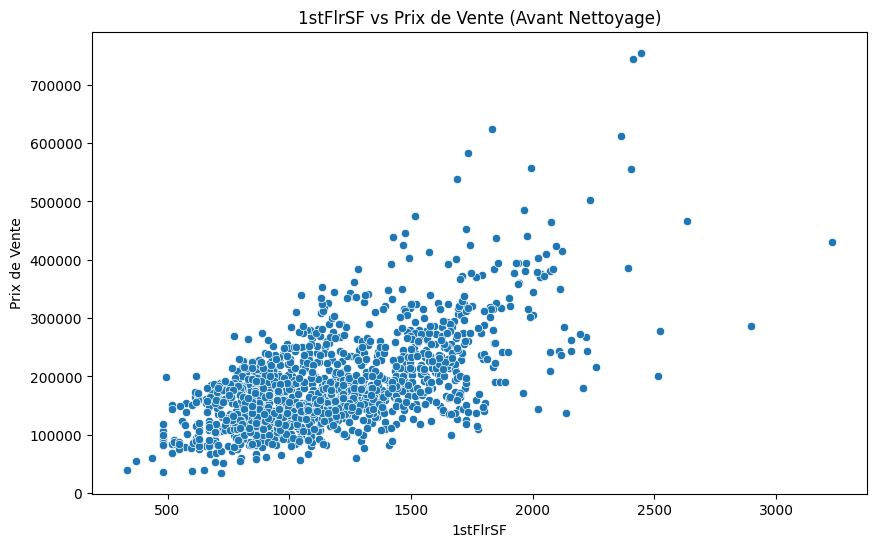


Aucun outlier détecté pour les critères définis


In [10]:
# Caractéristique 6
feature_name = top_10_cols[5]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = [] #train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


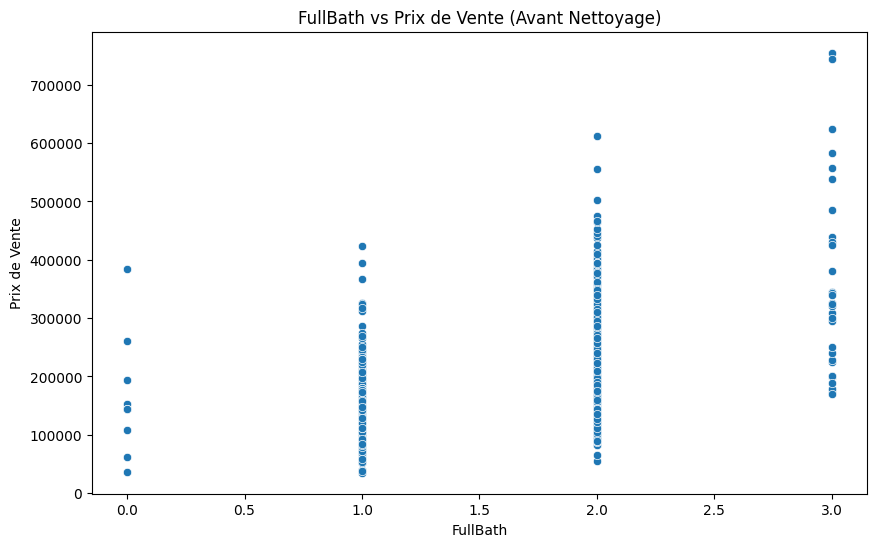


Aucun outlier détecté pour les critères définis


In [11]:
# Caractéristique 7
feature_name = top_10_cols[6]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = [] #train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")

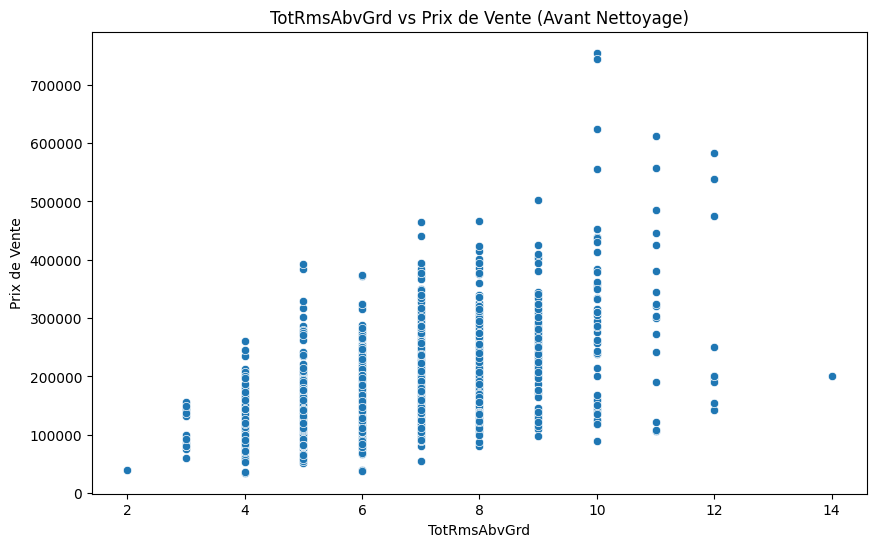


Outliers identifiés : 1
     TotRmsAbvGrd  SalePrice
635            14     200000


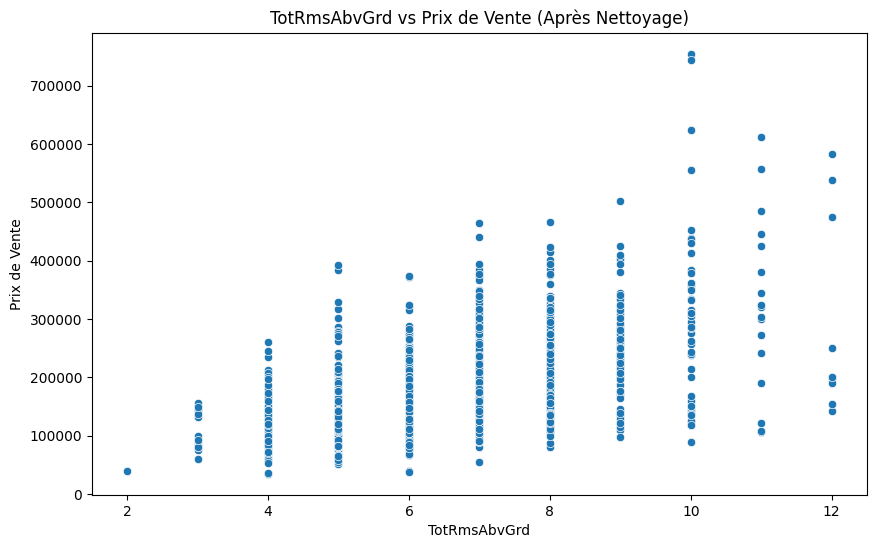

In [12]:
# Caractéristique 8
feature_name = top_10_cols[7]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] >= 14 )]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


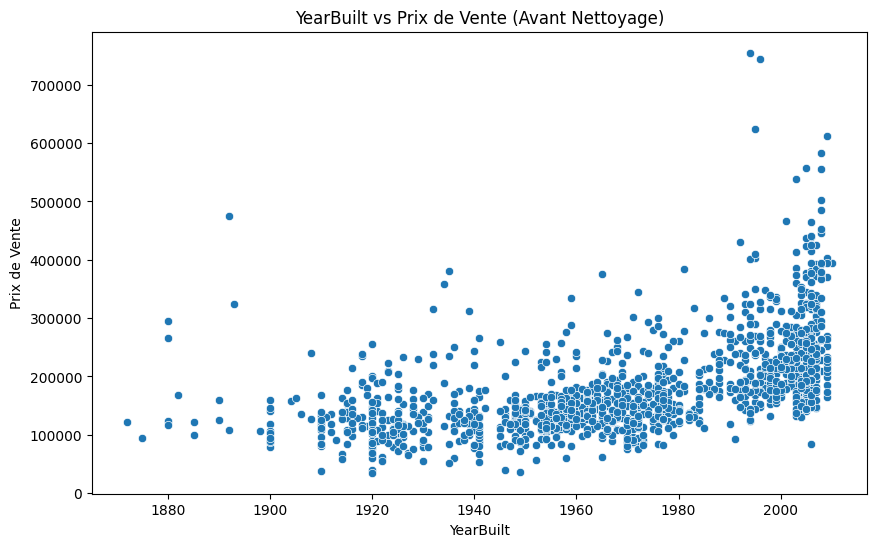


Outliers identifiés : 1
     YearBuilt  SalePrice
185       1892     475000


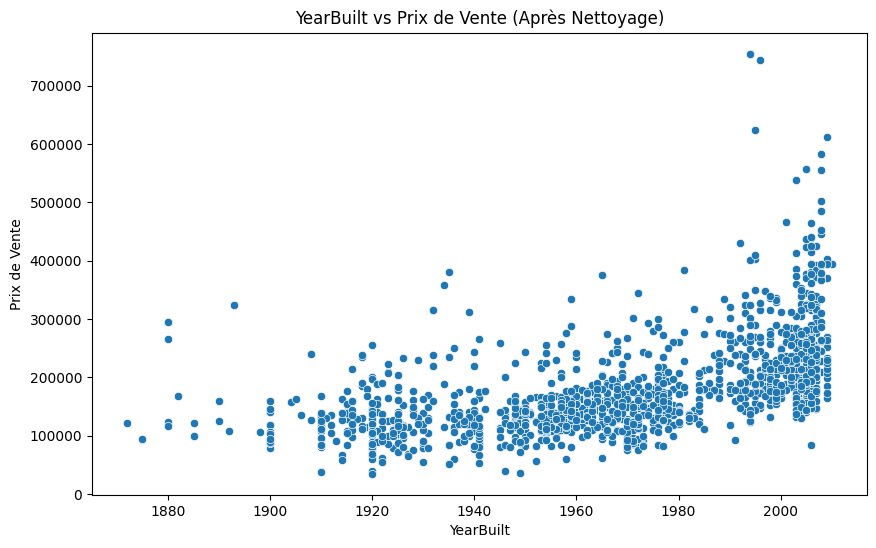

In [13]:
# Caractéristique 9
feature_name = top_10_cols[8]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] <= 1900 ) & (train_df['SalePrice'] > 400000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


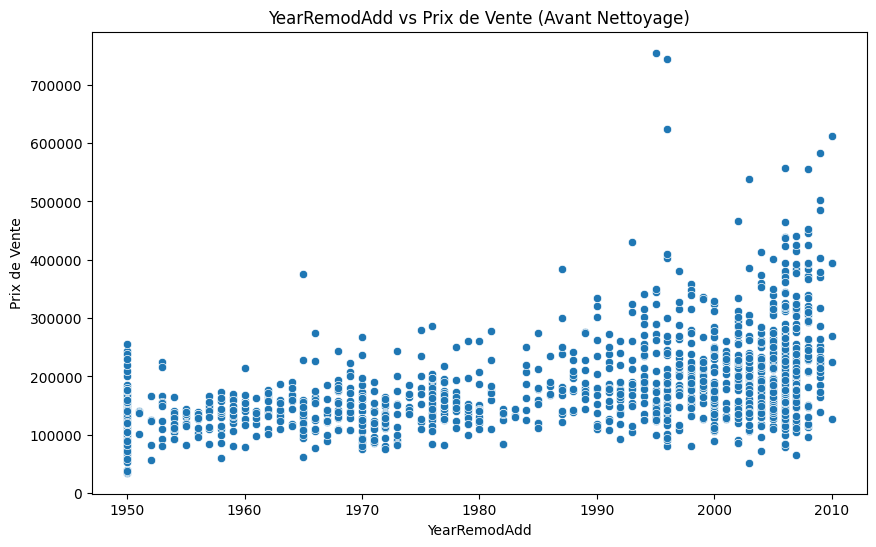


Outliers identifiés : 1
     YearRemodAdd  SalePrice
313          1965     375000


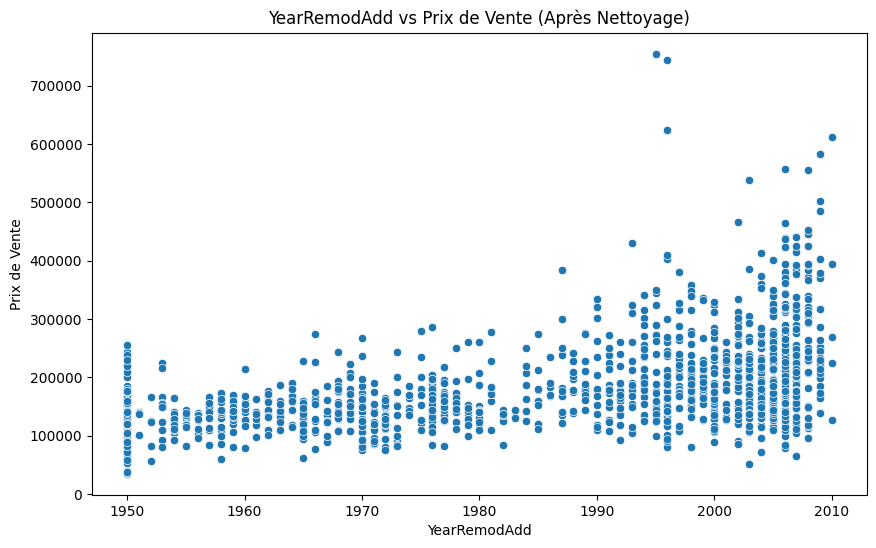

In [14]:
# Caractéristique 10
feature_name = top_10_cols[9]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] <= 1970 ) & (train_df['SalePrice'] >= 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


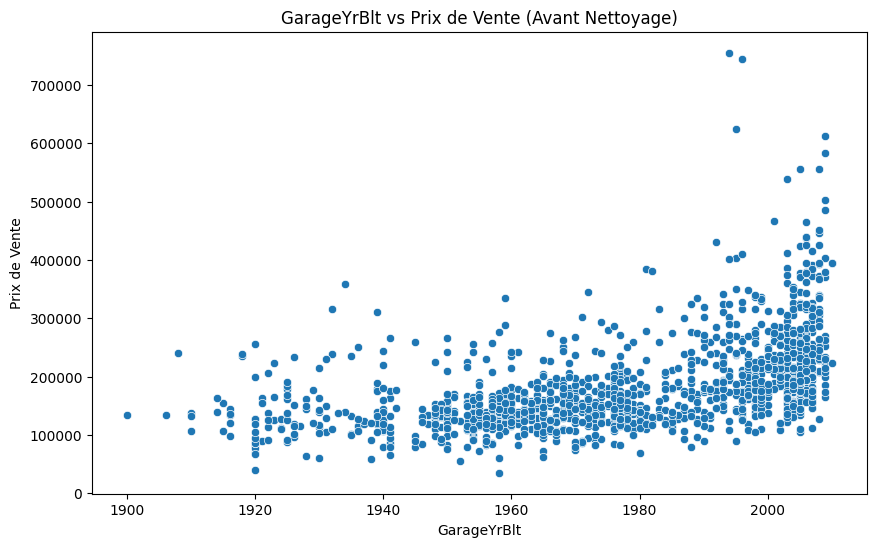


Aucun outlier détecté pour les critères définis


In [15]:
# Caractéristique 11
feature_name = top_10_cols[10]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()


outliers = [] # train_df[(train_df[feature_name] > 4000 ) &  (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")

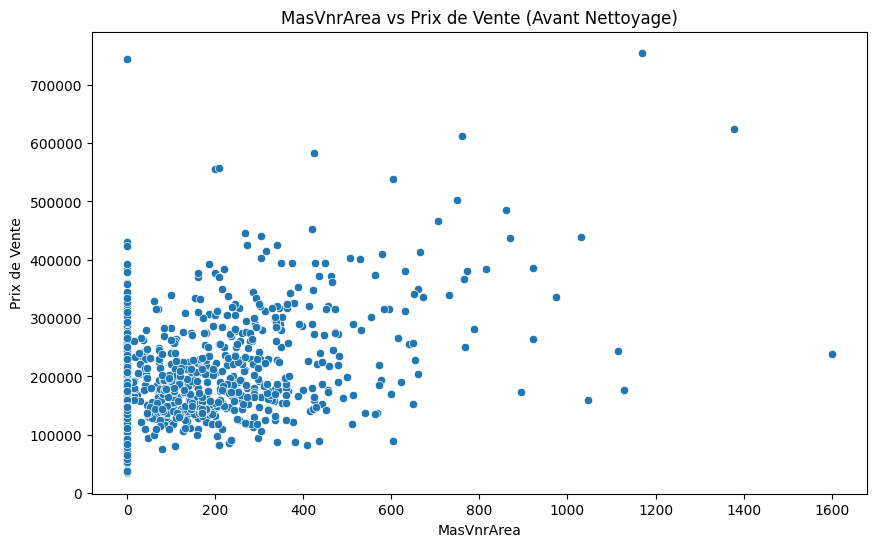


Outliers identifiés : 1
     MasVnrArea  SalePrice
297      1600.0     239000


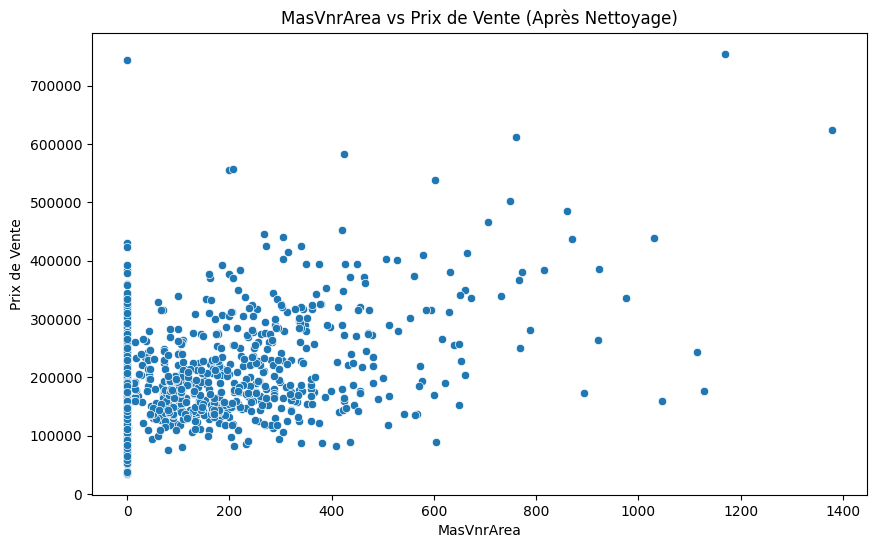

In [16]:
# Caractéristique 12
feature_name = top_10_cols[11]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()


outliers = train_df[(train_df[feature_name] > 1400 )]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")

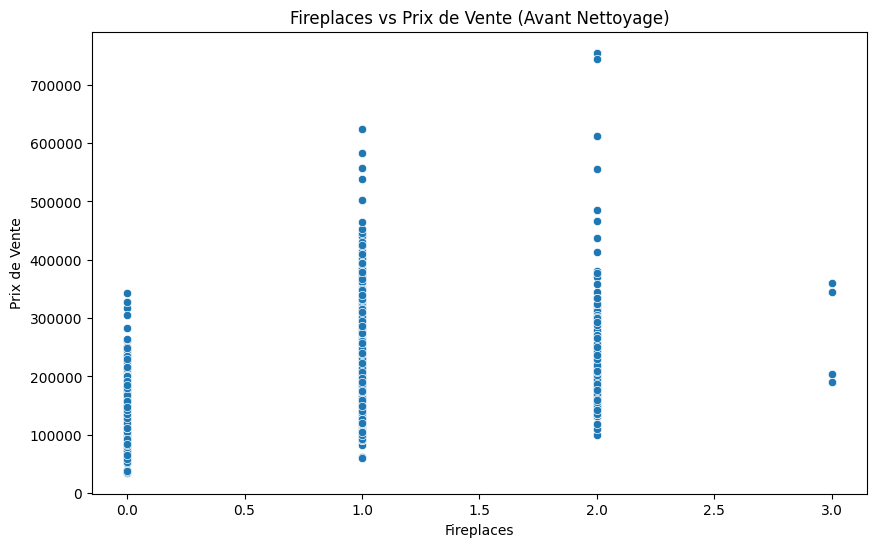


Aucun outlier détecté pour les critères définis


In [17]:
# Caractéristique 13
feature_name = top_10_cols[12]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()


outliers = [] # train_df[(train_df[feature_name] > 4000 ) &  (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")

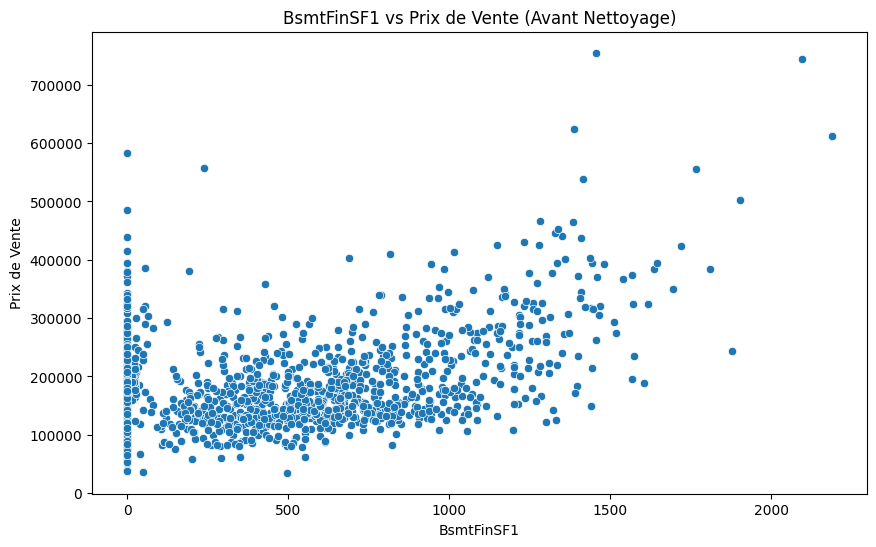


Aucun outlier détecté pour les critères définis


In [18]:
# Caractéristique 14
feature_name = top_10_cols[13]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = pd.concat([
    train_df[(train_df[feature_name] > 5000)],
    train_df[(train_df[feature_name] >= 2000) & (train_df['SalePrice'] < 300000)]
]).drop_duplicates()

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")

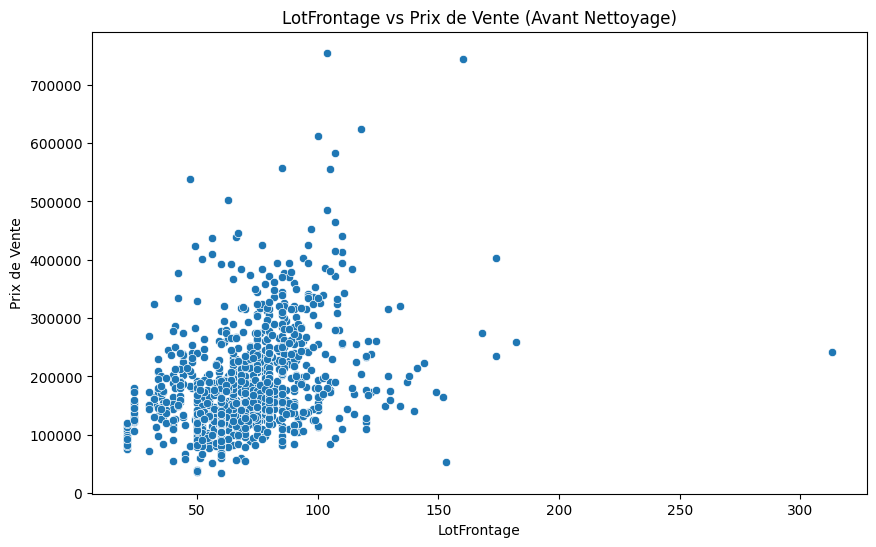


Outliers identifiés : 1
     LotFrontage  SalePrice
934        313.0     242000


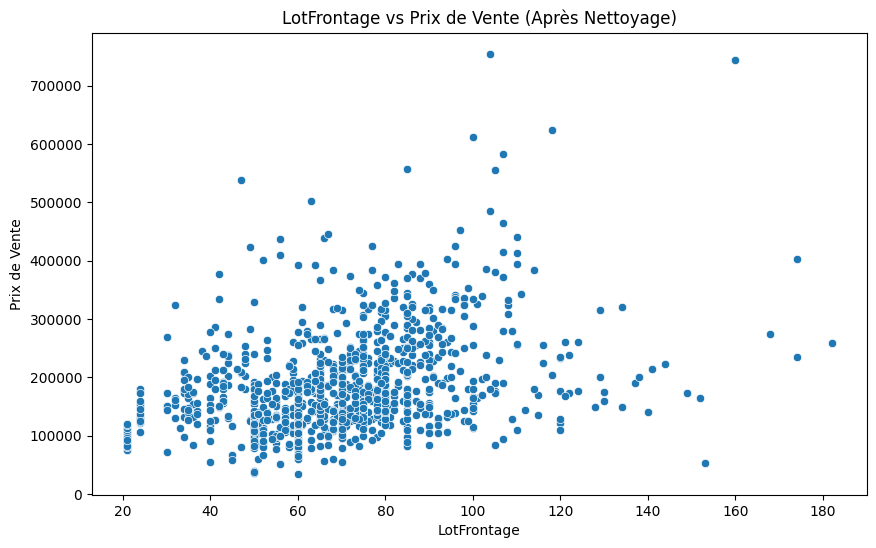

In [19]:
# Caractéristique 15
feature_name = top_10_cols[14]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()


outliers = train_df[(train_df[feature_name] > 300)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")

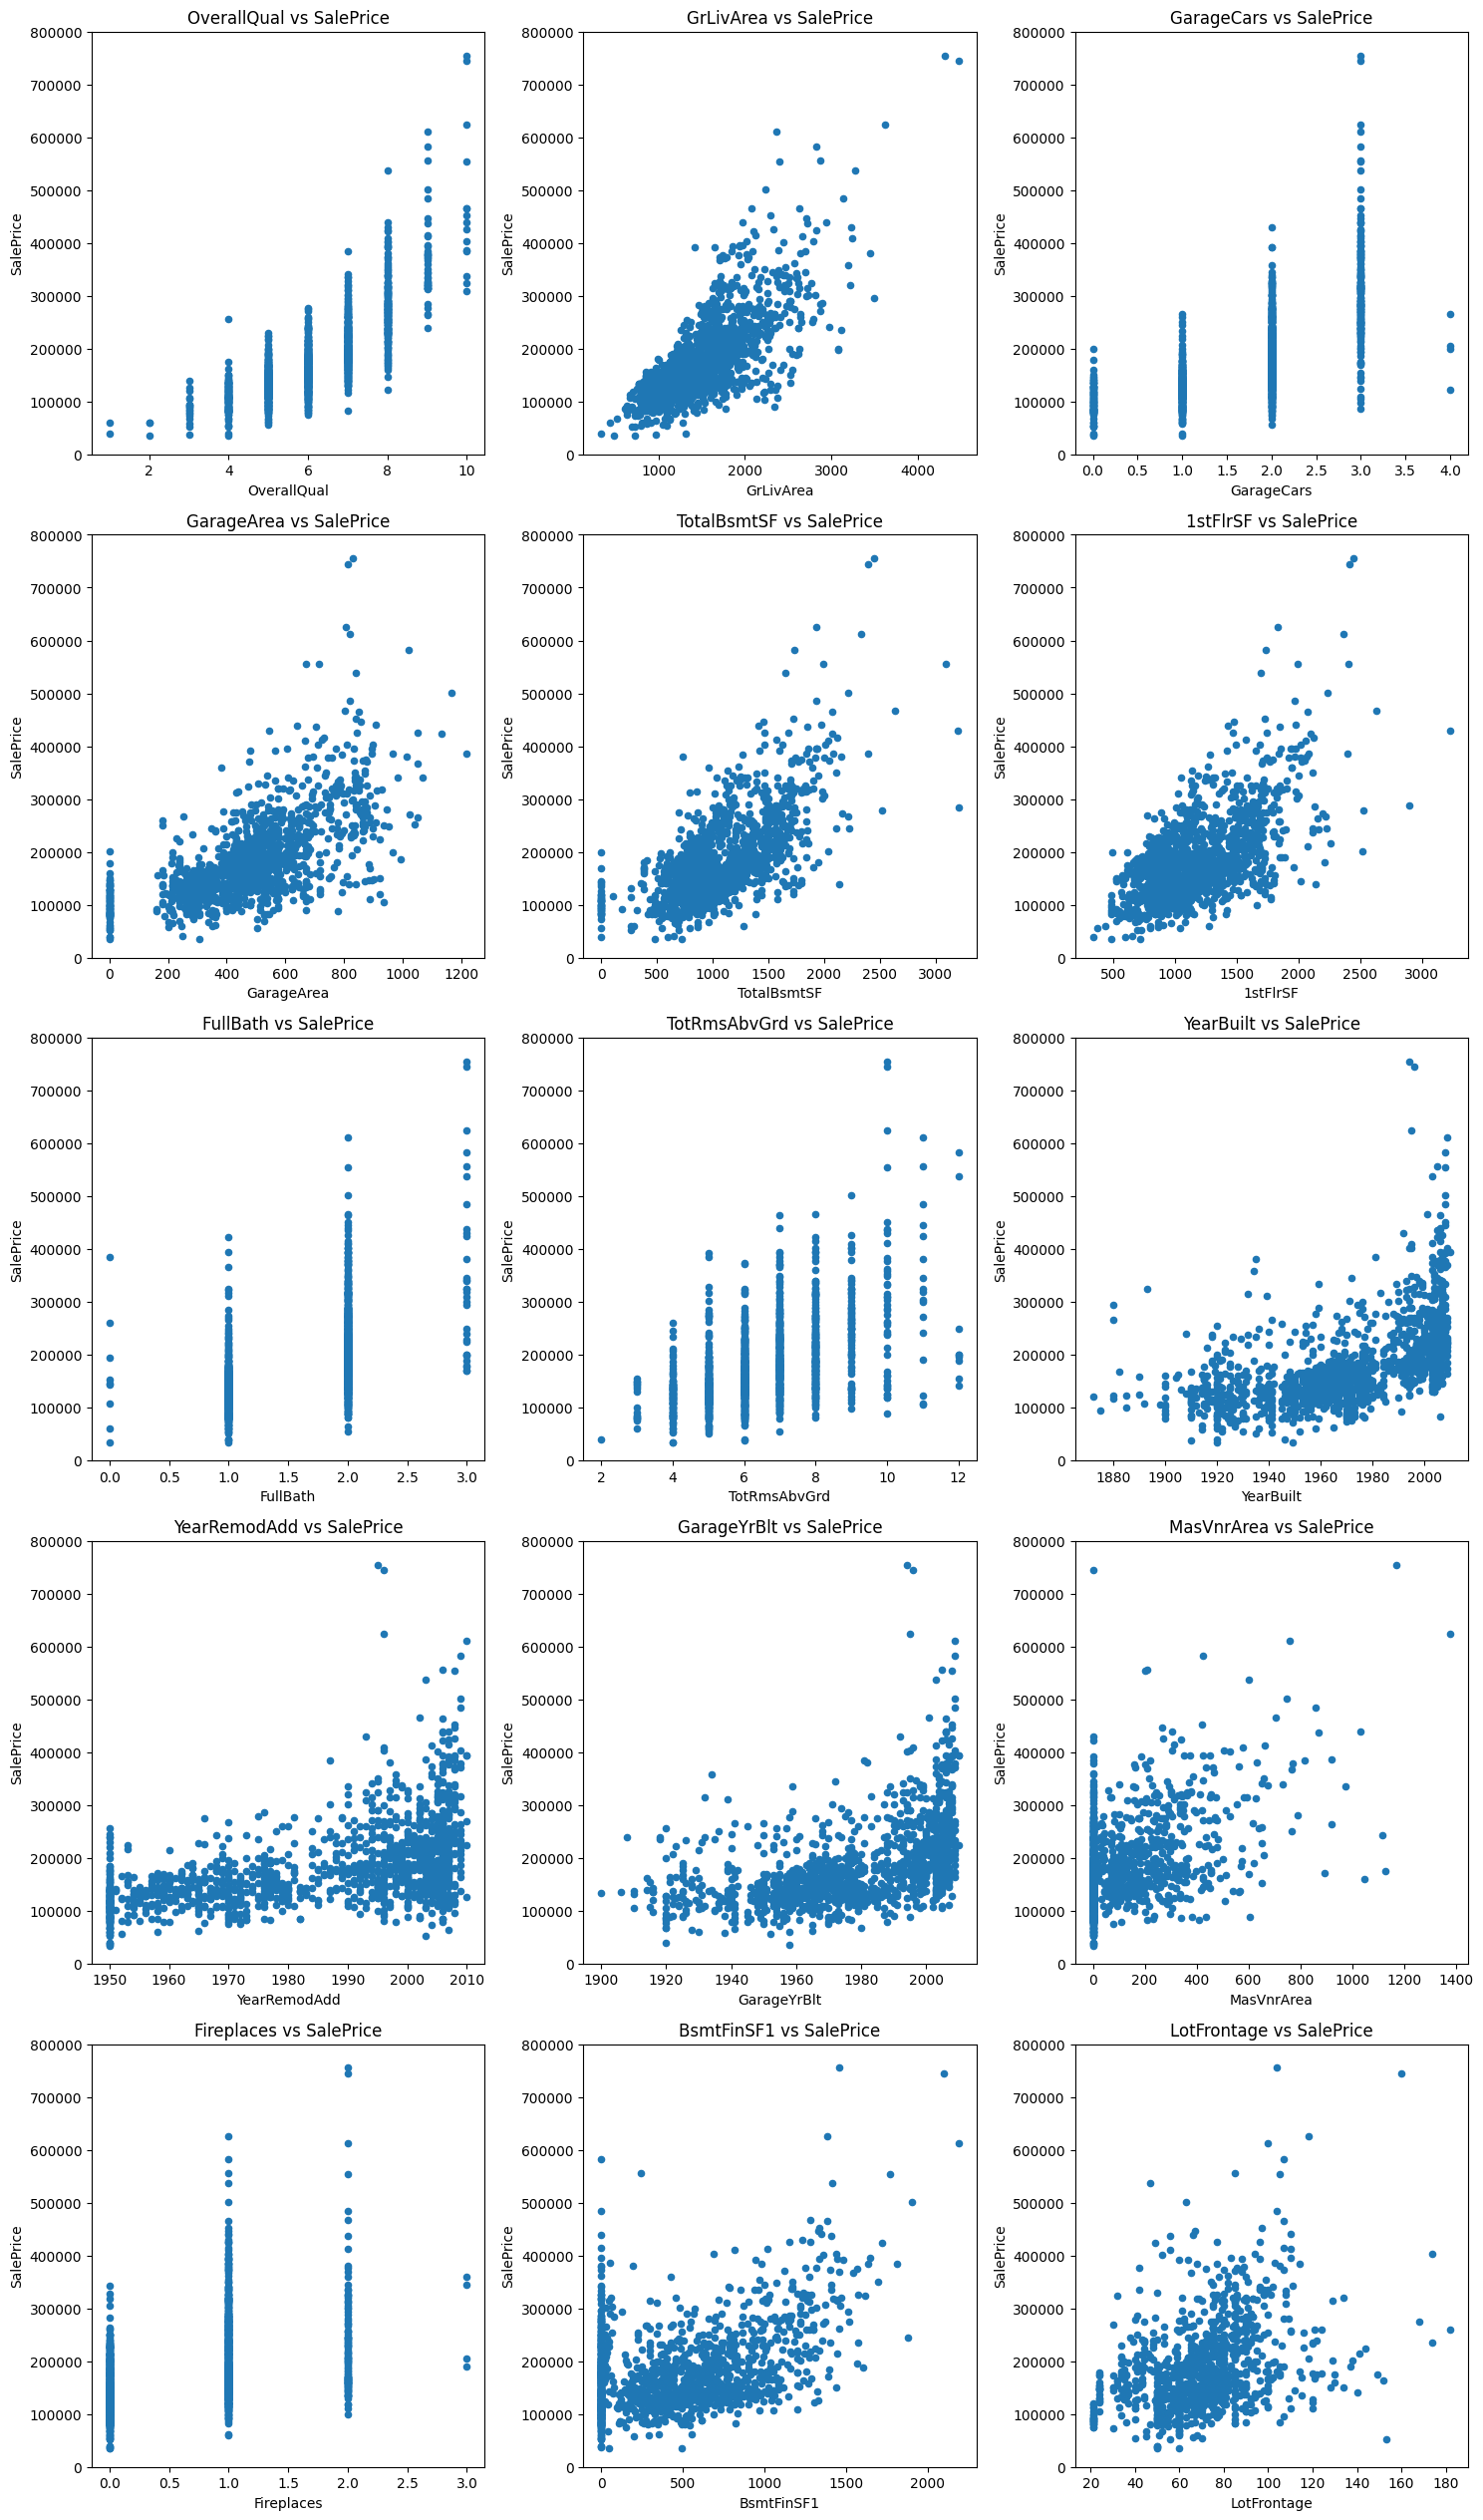

In [20]:
# Create subplots
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 5*(len(num_cols)//3 + 1)))
axes = axes.flatten()

for i, var in enumerate(num_cols):
    data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
    data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), ax=axes[i])
    axes[i].set_title(f'{var} vs SalePrice')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Pipeline 

In [21]:
# Préparation des données pour Feature Selection
X = train_df.drop(['SalePrice', 'Id'], axis=1)
y = train_df['SalePrice']
y_log = np.log1p(y)

# Imputer les valeurs manquantes AVANT la feature selection
numeric_features_full = X.select_dtypes(include=['int64', 'float64']).columns
imputer_num = SimpleImputer(strategy='median')
X_numeric_imputed = imputer_num.fit_transform(X[numeric_features_full])

# Sélectionner les meilleures features numériques
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_numeric_imputed, y_log)

# Trier par score
feature_scores = pd.DataFrame({
    'feature': numeric_features_full,
    'score': selector.scores_
}).sort_values('score', ascending=False)

# Garder seulement les top 20 features numériques
top_numeric_features = feature_scores.head(20)['feature'].tolist()
print(f"\nGardées {len(top_numeric_features)} features numériques")

# Toutes les features catégorielles
categorical_features_selected = X.select_dtypes(include=['object']).columns.tolist()
print(f"Gardées {len(categorical_features_selected)} features catégorielles")


Gardées 20 features numériques
Gardées 43 features catégorielles


In [22]:
# Utiliser les features sélectionnées
numeric_features = top_numeric_features
categorical_features = categorical_features_selected

print(f"\n=== PIPELINE ===")
print(f"Pipeline utilisant {len(numeric_features)} features numériques + {len(categorical_features)} features catégorielles")


=== PIPELINE ===
Pipeline utilisant 20 features numériques + 43 features catégorielles


In [23]:
# A. Pipeline pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Remplace NaN par la médiane
    ('scaler', RobustScaler())                     # Mise à l'échelle robuste aux outliers
])

# B. Pipeline pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')), # Remplace NaN par "None"
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Transforme en chiffres
])

# C. Assemblage du processeur final
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Entraînement du Modèle (Baseline)

In [24]:
# Séparation Train/Test (partagée pour tous les modèles)
print("=== PRÉPARATION DES DONNÉES ===")
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

# Split pour early stopping (validation interne)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Train : {X_tr.shape[0]} | Validation : {X_val.shape[0]}")

=== PRÉPARATION DES DONNÉES ===
Train : 1160 | Test : 290
Train : 928 | Validation : 232


#### Ridge

In [25]:
# 1. Création du Pipeline Ridge initial - BASELINE
ridge_model = Ridge(alpha=1.0)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ridge_model)
])

# 2. Entraînement baseline
ridge_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_ridge_baseline = ridge_pipeline.predict(X_test)
rmse_ridge_baseline = np.sqrt(mean_squared_error(y_test, y_pred_ridge_baseline))

print(f"Résultat du modèle Ridge avant optimisation : {rmse_ridge_baseline:.5f}")

# 4. Définition de la grille de paramètres pour Ridge
param_grid_ridge = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

# 5. Configurer la recherche
grid_search_ridge = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour Ridge...")
grid_search_ridge.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres Ridge trouvés : {grid_search_ridge.best_params_}")
best_score_ridge = -grid_search_ridge.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_ridge:.5f}")

# 8. Test final sur le jeu de test
best_ridge_pipeline = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge_pipeline.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Score final sur Test (Optimisé) : {rmse_ridge:.5f}")

Résultat du modèle Ridge avant optimisation : 0.12555
Recherche des meilleurs paramètres pour Ridge...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Meilleurs paramètres Ridge trouvés : {'model__alpha': 10.0}
Meilleur score CV (RMSE) : 0.11744
Score final sur Test (Optimisé) : 0.12291


#### XGCBoost

In [26]:
# 1. Définition du nouveau modèle (XGBoost)
# On utilise des paramètres standard pour commencer
xgb_model = XGBRegressor(
    n_estimators=1000,     # Nombre d'arbres (Semaine 11)
    learning_rate=0.05,    # Vitesse d'apprentissage
    n_jobs=-1,             # Utiliser tous les processeurs
    random_state=42
)

# 2. Création du Pipeline XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# 3. Entraînement
xgb_pipeline.fit(X_train, y_train)

# 4. Évaluation
y_pred_xgb = xgb_pipeline.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Résultat du modèle XGBoost): {rmse_xgb:.5f}")

Résultat du modèle XGBoost): 0.13052


In [27]:
# 1. Définir la grille des paramètres à tester
# On teste différentes profondeurs et vitesses d'apprentissage
param_grid = {
    'model__n_estimators': [1000, 1500],  # Nombre d'arbres
    'model__max_depth': [3, 5],           # Profondeur des arbres (éviter le sur-apprentissage)
    'model__learning_rate': [0.01, 0.05], # Vitesse (plus c'est petit, plus c'est précis mais lent)
    'model__subsample': [0.7]             # Pour éviter le sur-apprentissage (bagging interne)
}

# 2. Configurer la recherche
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', # Métrique de Kaggle
    cv=3,                                  # Validation croisée à 3 plis
    n_jobs=-1,                             # Utiliser tous les processeurs
    verbose=1
)

# 3. Lancer la recherche
print("Recherche des meilleurs paramètres en cours...")
grid_search.fit(X_train, y_train)

# 4. Résultats
print(f"\nMeilleurs paramètres trouvés : {grid_search.best_params_}")
best_score = -grid_search.best_score_
print(f"Meilleur score CV (RMSE) : {best_score:.5f}")

# 5. Test final sur le jeu de test avec le meilleur modèle
best_xgb_pipeline = grid_search.best_estimator_
y_pred_best = best_xgb_pipeline.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Score final sur Test (Optimisé) : {rmse_best:.5f}")

Recherche des meilleurs paramètres en cours...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Meilleurs paramètres trouvés : {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 1500, 'model__subsample': 0.7}
Meilleur score CV (RMSE) : 0.12508
Score final sur Test (Optimisé) : 0.11997


#### LightGBM

In [28]:
# 1. Création du Pipeline LightGBM initial - BASELINE
lgbm_model = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=6, random_state=42, verbose=-1)
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgbm_model)
])

# 2. Entraînement baseline
lgbm_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_lgbm_baseline = lgbm_pipeline.predict(X_test)
rmse_lgbm_baseline = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_baseline))

print(f"Résultat du modèle LightGBM avant optimisation : {rmse_lgbm_baseline:.5f}")

# 4. Définition de la grille de paramètres pour LightGBM
param_grid_lgbm = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [3, 5],
    'model__num_leaves': [4, 6],
    'model__learning_rate': [0.01, 0.05]
}

# 5. Configurer la recherche
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid_lgbm,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour LightGBM...")
grid_search_lgbm.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres LightGBM trouvés : {grid_search_lgbm.best_params_}")
best_score_lgbm = -grid_search_lgbm.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_lgbm:.5f}")

# 8. Test final sur le jeu de test
best_lgbm_pipeline = grid_search_lgbm.best_estimator_
y_pred_lgbm = best_lgbm_pipeline.predict(X_test)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print(f"Score final sur Test (Optimisé) : {rmse_lgbm:.5f}")

c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Résultat du modèle LightGBM avant optimisation : 0.13219
Recherche des meilleurs paramètres pour LightGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Meilleurs paramètres LightGBM trouvés : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__num_leaves': 4}
Meilleur score CV (RMSE) : 0.12585
Score final sur Test (Optimisé) : 0.12931


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#### Lasso 

In [29]:
# 1. Création du Pipeline Lasso initial - BASELINE
lasso_model = Lasso(alpha=0.1, max_iter=5000, random_state=42)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lasso_model)
])

# 2. Entraînement baseline
lasso_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_lasso_baseline = lasso_pipeline.predict(X_test)
rmse_lasso_baseline = np.sqrt(mean_squared_error(y_test, y_pred_lasso_baseline))

print(f"Résultat du modèle Lasso avant optimisation : {rmse_lasso_baseline:.5f}")

# 4. Définition de la grille de paramètres pour Lasso
param_grid_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
}

# 5. Configurer la recherche
grid_search_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid_lasso,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour Lasso...")
grid_search_lasso.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres Lasso trouvés : {grid_search_lasso.best_params_}")
best_score_lasso = -grid_search_lasso.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_lasso:.5f}")

# 8. Test final sur le jeu de test
best_lasso_pipeline = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso_pipeline.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"Score final sur Test (Optimisé) : {rmse_lasso:.5f}")

Résultat du modèle Lasso avant optimisation : 0.23043
Recherche des meilleurs paramètres pour Lasso...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Meilleurs paramètres Lasso trouvés : {'model__alpha': 0.001}
Meilleur score CV (RMSE) : 0.12019
Score final sur Test (Optimisé) : 0.12092


#### RandomForest

In [30]:
# 1. Création du Pipeline RandomForest initial - BASELINE
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# 2. Entraînement baseline
rf_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_rf_baseline = rf_pipeline.predict(X_test)
rmse_rf_baseline = np.sqrt(mean_squared_error(y_test, y_pred_rf_baseline))

print(f"Résultat du modèle RandomForest avant optimisation : {rmse_rf_baseline:.5f}")

# 4. Définition de la grille de paramètres pour RandomForest
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [2, 5],
}

# 5. Configurer la recherche
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour RandomForest...")
grid_search_rf.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres RandomForest trouvés : {grid_search_rf.best_params_}")
best_score_rf = -grid_search_rf.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_rf:.5f}")

# 8. Test final sur le jeu de test
best_rf_pipeline = grid_search_rf.best_estimator_
y_pred_rf = best_rf_pipeline.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Score final sur Test (Optimisé) : {rmse_rf:.5f}")

Résultat du modèle RandomForest avant optimisation : 0.13664
Recherche des meilleurs paramètres pour RandomForest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Meilleurs paramètres RandomForest trouvés : {'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Meilleur score CV (RMSE) : 0.14880
Score final sur Test (Optimisé) : 0.13440


#### GradientBoosting

In [31]:
# 1. Création du Pipeline GradientBoosting initial - BASELINE
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', gb_model)
])

# 2. Entraînement baseline
gb_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_gb_baseline = gb_pipeline.predict(X_test)
rmse_gb_baseline = np.sqrt(mean_squared_error(y_test, y_pred_gb_baseline))

print(f"Résultat du modèle GradientBoosting avant optimisation : {rmse_gb_baseline:.5f}")

# 4. Définition de la grille de paramètres pour GradientBoosting
param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5],
}

# 5. Configurer la recherche
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour GradientBoosting...")
grid_search_gb.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres GradientBoosting trouvés : {grid_search_gb.best_params_}")
best_score_gb = -grid_search_gb.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_gb:.5f}")

# 8. Test final sur le jeu de test
best_gb_pipeline = grid_search_gb.best_estimator_
y_pred_gb = best_gb_pipeline.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Score final sur Test (Optimisé) : {rmse_gb:.5f}")

Résultat du modèle GradientBoosting avant optimisation : 0.12905
Recherche des meilleurs paramètres pour GradientBoosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Meilleurs paramètres GradientBoosting trouvés : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Meilleur score CV (RMSE) : 0.12939
Score final sur Test (Optimisé) : 0.12626


#### Mélange 

In [32]:
# 1. Générer les prédictions sur le jeu d'ENTRAÎNEMENT pour les poids
# (Pas sur X_test pour éviter la fuite d'information)
pred_ridge_train = best_ridge_pipeline.predict(X_train)
pred_xgb_train = best_xgb_pipeline.predict(X_train)
pred_lgbm_train = best_lgbm_pipeline.predict(X_train)
pred_lasso_train = best_lasso_pipeline.predict(X_train)

# 2. Recherche des poids optimaux
from sklearn.linear_model import LinearRegression

# Créer une matrice des prédictions (4 modèles)
X_meta = np.column_stack([pred_ridge_train, pred_xgb_train, pred_lgbm_train, pred_lasso_train])

# Entraîner un modèle linéaire pour trouver les meilleurs poids
meta_model = LinearRegression()
meta_model.fit(X_meta, y_train)

# Les coefficients du modèle linéaire sont nos poids optimaux
weights = meta_model.coef_
weights_normalized = weights / weights.sum()  # Normaliser les poids

print(f"\nPoids optimaux trouvés :")
print(f"  Ridge  : {weights_normalized[0]:.4f}")
print(f"  XGBoost: {weights_normalized[1]:.4f}")
print(f"  LightGBM: {weights_normalized[2]:.4f}")
print(f"  Lasso  : {weights_normalized[3]:.4f}")

# 3. Générer les prédictions sur le jeu de TEST pour l'évaluation
pred_ridge = best_ridge_pipeline.predict(X_test)
pred_xgb = best_xgb_pipeline.predict(X_test)
pred_lgbm = best_lgbm_pipeline.predict(X_test)
pred_lasso = best_lasso_pipeline.predict(X_test)

# 4. Appliquer les poids optimaux sur le test
final_pred_test = (weights_normalized[0] * pred_ridge + 
                   weights_normalized[1] * pred_xgb + 
                   weights_normalized[2] * pred_lgbm + 
                   weights_normalized[3] * pred_lasso)

# 5. Calculer le score final
rmse_blend = np.sqrt(mean_squared_error(y_test, final_pred_test))

print(f"\n" + "="*60)
print("RÉSUMÉ DES PERFORMANCES")
print("="*60)
print(f"Ridge         : {rmse_ridge:.5f}")
print(f"XGBoost       : {rmse_best:.5f}")
print(f"LightGBM      : {rmse_lgbm:.5f}")
print(f"Lasso         : {rmse_lasso:.5f}")
print(f"Blending (opt): {rmse_blend:.5f}")
print(f"\nMeilleur score : {min(rmse_ridge, rmse_best, rmse_lgbm, rmse_lasso, rmse_blend):.5f}")


Poids optimaux trouvés :
  Ridge  : 0.3556
  XGBoost: 1.6056
  LightGBM: -0.3955
  Lasso  : -0.5657

RÉSUMÉ DES PERFORMANCES
Ridge         : 0.12291
XGBoost       : 0.11997
LightGBM      : 0.12931
Lasso         : 0.12092
Blending (opt): 0.12349

Meilleur score : 0.11997


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [33]:
# 1. Charger les données de test (celles sans le prix)
test_df = pd.read_csv('input/house-prices-advanced-regression-techniques/test.csv')

# Sauvegarder les IDs pour le fichier final
test_ids = test_df['Id']

# 2. Préparer les données de test comme on a préparé X_train
X_test_final = test_df.drop('Id', axis=1)

# 3. Générer les prédictions sur le jeu de test Kaggle
pred_ridge_test = best_ridge_pipeline.predict(X_test_final)
pred_xgb_test = best_xgb_pipeline.predict(X_test_final)
pred_lgbm_test = best_lgbm_pipeline.predict(X_test_final)
pred_lasso_test = best_lasso_pipeline.predict(X_test_final)

# 4. Appliquer les poids optimaux trouvés pendant l'entraînement
final_pred_log = (weights_normalized[0] * pred_ridge_test + 
                  weights_normalized[1] * pred_xgb_test + 
                  weights_normalized[2] * pred_lgbm_test + 
                  weights_normalized[3] * pred_lasso_test)

# 5. Inverser la transformation log (puisqu'on avait fait np.log1p)
final_pred = np.expm1(final_pred_log)

# 6. Créer le fichier de soumission
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_pred
})

# Sauvegarde
submission.to_csv('submission.csv', index=False)
print("Fichier 'submission.csv' généré avec succès !")
print(f"Nombre de prédictions : {len(submission)}")
print(f"Aperçu des premières prédictions :")
print(submission.head())

Fichier 'submission.csv' généré avec succès !
Nombre de prédictions : 1459
Aperçu des premières prédictions :
     Id      SalePrice
0  1461  128798.974201
1  1462  162010.807819
2  1463  197645.316949
3  1464  191731.197349
4  1465  192863.866940


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [34]:
# ========== STACKING AVANCÉ (Meilleur que Blending) ==========
print("\n" + "="*70)
print("CONSTRUCTION DU MODÈLE DE STACKING")
print("="*70)

# 1. Générer les prédictions de validation croisée (sans fuite de données!)
print("Génération des prédictions de stacking (validation croisée)...")

pred_ridge_meta = cross_val_predict(best_ridge_pipeline, X_train, y_train, cv=5)
pred_xgb_meta = cross_val_predict(best_xgb_pipeline, X_train, y_train, cv=5)
pred_lgbm_meta = cross_val_predict(best_lgbm_pipeline, X_train, y_train, cv=5)
pred_lasso_meta = cross_val_predict(best_lasso_pipeline, X_train, y_train, cv=5)
pred_rf_meta = cross_val_predict(best_rf_pipeline, X_train, y_train, cv=5)
pred_gb_meta = cross_val_predict(best_gb_pipeline, X_train, y_train, cv=5)

# 2. Créer la matrice de features meta-modèle
X_meta_train = np.column_stack([
    pred_ridge_meta, pred_xgb_meta, pred_lgbm_meta,
    pred_lasso_meta, pred_rf_meta, pred_gb_meta
])

print(f"Matrice de stacking (train) : {X_meta_train.shape}")

# 3. Entraîner le meta-modèle avec Ridge (régularisé pour éviter l'overfitting)
meta_model = Ridge(alpha=1.0)
meta_model.fit(X_meta_train, y_train)

# Obtenir les poids
weights = meta_model.coef_
weights_normalized = weights / weights.sum()

print(f"\nPoids optimaux trouvés (Stacking) :")
print(f"  Ridge        : {weights_normalized[0]:.4f}")
print(f"  XGBoost      : {weights_normalized[1]:.4f}")
print(f"  LightGBM     : {weights_normalized[2]:.4f}")
print(f"  Lasso        : {weights_normalized[3]:.4f}")
print(f"  RandomForest : {weights_normalized[4]:.4f}")
print(f"  GradBoosting : {weights_normalized[5]:.4f}")

# 4. Générer les prédictions sur le jeu de TEST
print("\nGénération des prédictions finales...")
pred_ridge_test = best_ridge_pipeline.predict(X_test)
pred_xgb_test = best_xgb_pipeline.predict(X_test)
pred_lgbm_test = best_lgbm_pipeline.predict(X_test)
pred_lasso_test = best_lasso_pipeline.predict(X_test)
pred_rf_test = best_rf_pipeline.predict(X_test)
pred_gb_test = best_gb_pipeline.predict(X_test)

# Assembler la matrice de test
X_meta_test = np.column_stack([
    pred_ridge_test, pred_xgb_test, pred_lgbm_test,
    pred_lasso_test, pred_rf_test, pred_gb_test
])

# 5. Appliquer le meta-modèle
final_pred_stacking = meta_model.predict(X_meta_test)
rmse_stacking = np.sqrt(mean_squared_error(y_test, final_pred_stacking))

# Alternative simple : moyenne pondérée
final_pred_blend = (
    weights_normalized[0] * pred_ridge_test + 
    weights_normalized[1] * pred_xgb_test + 
    weights_normalized[2] * pred_lgbm_test + 
    weights_normalized[3] * pred_lasso_test +
    weights_normalized[4] * pred_rf_test +
    weights_normalized[5] * pred_gb_test
)

rmse_blend = np.sqrt(mean_squared_error(y_test, final_pred_blend))

# 6. Affichage final complet
print(f"\n" + "="*70)
print("RÉSUMÉ FINAL DES PERFORMANCES (6 Modèles + Ensemble)")
print("="*70)
print(f"Ridge           (optimisé)  : {rmse_ridge:.5f}")
print(f"XGBoost         (optimisé)  : {rmse_best:.5f}")
print(f"LightGBM        (optimisé)  : {rmse_lgbm:.5f}")
print(f"Lasso           (optimisé)  : {rmse_lasso:.5f}")
print(f"RandomForest    (optimisé)  : {rmse_rf:.5f}")
print(f"GradientBoosting(optimisé)  : {rmse_gb:.5f}")
print("-" * 70)
print(f"Blending (moyenne pondérée) : {rmse_blend:.5f}")
print(f"Stacking (meta-modèle Ridge): {rmse_stacking:.5f}")
print("="*70)

best_score_final = min(rmse_ridge, rmse_best, rmse_lgbm, rmse_lasso, rmse_rf, rmse_gb, rmse_blend, rmse_stacking)
best_model_name = [
    ('Ridge', rmse_ridge),
    ('XGBoost', rmse_best),
    ('LightGBM', rmse_lgbm),
    ('Lasso', rmse_lasso),
    ('RandomForest', rmse_rf),
    ('GradientBoosting', rmse_gb),
    ('Blending', rmse_blend),
    ('Stacking', rmse_stacking)
]
best_model_name = max(best_model_name, key=lambda x: -x[1])

print(f"Meilleur modèle : {best_model_name[0]} avec RMSE = {best_model_name[1]:.5f}")
print("="*70)


CONSTRUCTION DU MODÈLE DE STACKING
Génération des prédictions de stacking (validation croisée)...


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\

Matrice de stacking (train) : (1160, 6)

Poids optimaux trouvés (Stacking) :
  Ridge        : 0.3922
  XGBoost      : 0.2549
  LightGBM     : 0.1305
  Lasso        : 0.2363
  RandomForest : -0.0634
  GradBoosting : 0.0494

Génération des prédictions finales...

RÉSUMÉ FINAL DES PERFORMANCES (6 Modèles + Ensemble)
Ridge           (optimisé)  : 0.12291
XGBoost         (optimisé)  : 0.11997
LightGBM        (optimisé)  : 0.12931
Lasso           (optimisé)  : 0.12092
RandomForest    (optimisé)  : 0.13440
GradientBoosting(optimisé)  : 0.12626
----------------------------------------------------------------------
Blending (moyenne pondérée) : 0.11938
Stacking (meta-modèle Ridge): 0.11948
Meilleur modèle : Blending avec RMSE = 0.11938


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



TABLEAU COMPLET DES MÉTRIQUES
           Model     RMSE      MAE       R²
        Blending 0.119376 0.082673 0.907630
        Stacking 0.119483 0.082979 0.907464
         XGBoost 0.119966 0.081826 0.906714
           Lasso 0.120924 0.085930 0.905218
           Ridge 0.122911 0.085755 0.902078
GradientBoosting 0.126264 0.087172 0.896663
        LightGBM 0.129305 0.086223 0.891624
    RandomForest 0.134402 0.088131 0.882913


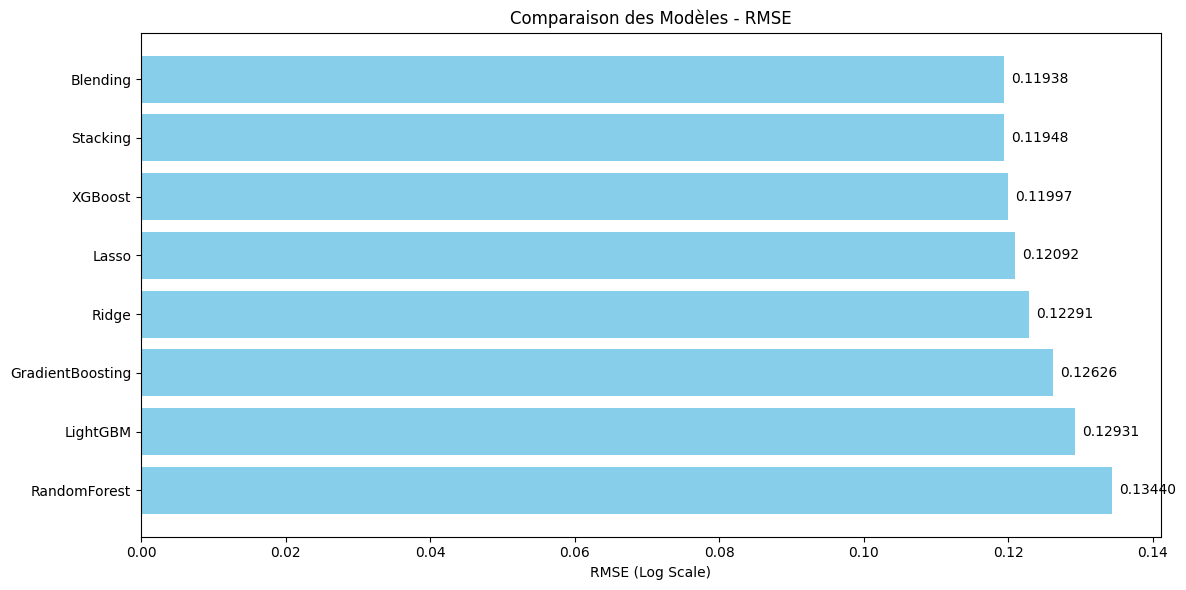

In [35]:
# Calculer des métriques supplémentaires
def calculate_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

metrics_list = [
    calculate_metrics(y_test, y_pred_ridge, 'Ridge'),
    calculate_metrics(y_test, y_pred_best, 'XGBoost'),
    calculate_metrics(y_test, y_pred_lgbm, 'LightGBM'),
    calculate_metrics(y_test, y_pred_lasso, 'Lasso'),
    calculate_metrics(y_test, y_pred_rf, 'RandomForest'),
    calculate_metrics(y_test, y_pred_gb, 'GradientBoosting'),
    calculate_metrics(y_test, final_pred_blend, 'Blending'),
    calculate_metrics(y_test, final_pred_stacking, 'Stacking'),
]

metrics_df = pd.DataFrame(metrics_list).sort_values('RMSE')
print("\n" + "="*70)
print("TABLEAU COMPLET DES MÉTRIQUES")
print("="*70)
print(metrics_df.to_string(index=False))
print("="*70)

# Visualiser les résultats
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df_sorted = metrics_df.sort_values('RMSE')
ax.barh(metrics_df_sorted['Model'], metrics_df_sorted['RMSE'], color='skyblue')
ax.set_xlabel('RMSE (Log Scale)')
ax.set_title('Comparaison des Modèles - RMSE')
ax.invert_yaxis()
for i, v in enumerate(metrics_df_sorted['RMSE']):
    ax.text(v + 0.001, i, f'{v:.5f}', va='center')
plt.tight_layout()
plt.show()

In [36]:
# 1. Charger les données de test (celles sans le prix)
test_df = pd.read_csv('input/house-prices-advanced-regression-techniques/test.csv')

# Sauvegarder les IDs pour le fichier final
test_ids = test_df['Id']

# 2. Attention : Le pipeline attend les mêmes colonnes que l'entraînement
# On doit s'assurer que test_df a la même structure (sauf SalePrice bien sûr)
# Normalement, votre 'preprocessor' gère ça, mais il faut parfois gérer des catégories inconnues
# (C'est géré par handle_unknown='ignore' dans votre OneHotEncoder, donc tout va bien !)

# 3. Générer les prédictions avec le meilleur modèle (ici on utilise le stacking)
# Préparer X pour la prédiction (retirer Id)
X_test_final = test_df.drop(['Id'], axis=1)

# Générer les prédictions de tous les modèles sur test_df
pred_ridge_final = best_ridge_pipeline.predict(X_test_final)
pred_xgb_final = best_xgb_pipeline.predict(X_test_final)
pred_lgbm_final = best_lgbm_pipeline.predict(X_test_final)
pred_lasso_final = best_lasso_pipeline.predict(X_test_final)
pred_rf_final = best_rf_pipeline.predict(X_test_final)
pred_gb_final = best_gb_pipeline.predict(X_test_final)

# Assembler la matrice pour le meta-modèle
X_meta_final = np.column_stack([
    pred_ridge_final, pred_xgb_final, pred_lgbm_final,
    pred_lasso_final, pred_rf_final, pred_gb_final
])

# Appliquer le meta-modèle de stacking
final_predictions_log = meta_model.predict(X_meta_final)

# Convertir de log à prix réel
final_predictions = np.expm1(final_predictions_log)

# 4. Créer le fichier de soumission
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions
})



# Sauvegarde
submission.to_csv('submission.csv', index=False)
print("Fichier 'submission.csv' généré avec succès !")

Fichier 'submission.csv' généré avec succès !


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
